In [32]:
import nibabel as nib
import importlib
import gimmeJig
importlib.reload(gimmeJig)

<module 'gimmeJig' from '/home/coder/gimmeJig/gimmeJig.py'>

In [33]:
brain_example_path = '/Volumes/Siren/Brain_data/1.PatientDirectory/101/MRI/Processed/20101012_Mr_Brain_Wo+W_Cont_Ss/brainmask.nii.gz'
prostate_example_path = '/Volumes/Siren/Prostate_data/1101/MRI/Processed/prostate_mask.nii.gz'

### Step 1: NIfTI Loading
Load a mask volume with `gimmeJig.load_nifti` and inspect basic metadata before deeper processing.

In [34]:
from pathlib import Path

def load_and_summarize(path_str: str):
    path = Path(path_str).expanduser()
    if not path.exists():
        print(f"Skipping load; missing file: {path}")
        return None
    volume = gimmeJig.load_nifti(path)
    print(volume.summary())
    return volume

brain_volume = load_and_summarize(brain_example_path)
prostate_volume = load_and_summarize(prostate_example_path)

NiftiVolume(path=/Volumes/Siren/Brain_data/1.PatientDirectory/101/MRI/Processed/20101012_Mr_Brain_Wo+W_Cont_Ss/brainmask.nii.gz, shape=(204, 273, 190), voxel_spacing=(1.000, 1.000, 1.000), orientation=LPS)
NiftiVolume(path=/Volumes/Siren/Prostate_data/1101/MRI/Processed/prostate_mask.nii.gz, shape=(512, 512, 32), voxel_spacing=(0.234, 0.234, 3.000), orientation=LPI)
NiftiVolume(path=/Volumes/Siren/Prostate_data/1101/MRI/Processed/prostate_mask.nii.gz, shape=(512, 512, 32), voxel_spacing=(0.234, 0.234, 3.000), orientation=LPI)


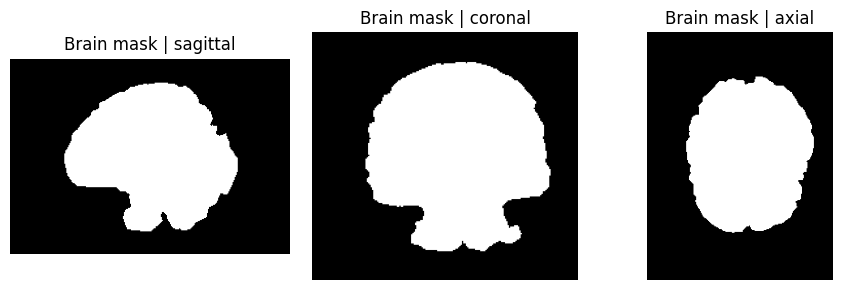

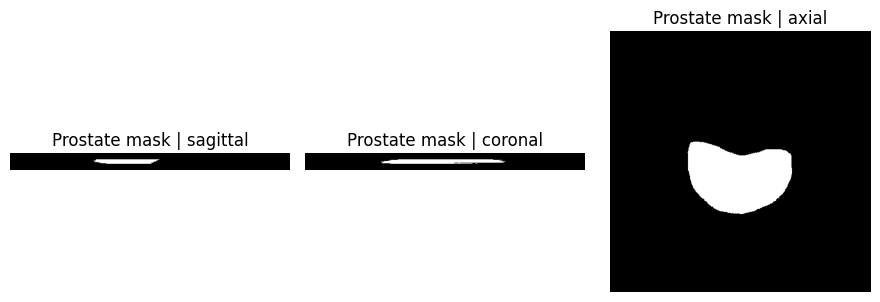

In [35]:
import matplotlib.pyplot as plt
import numpy as np

def show_middle_slices(volume, title: str):
    data = np.asarray(volume.data)
    if data.ndim > 3:
        data = data[..., 0]
    mids = [dim // 2 for dim in data.shape[:3]]
    slices = [
        data[mids[0], :, :],
        data[:, mids[1], :],
        data[:, :, mids[2]],
    ]
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for ax, slc, axis_label in zip(axes, slices, ("sagittal", "coronal", "axial")):
        ax.imshow(np.rot90(slc), cmap="gray")
        ax.set_title(f"{title} | {axis_label}")
        ax.axis("off")
    fig.tight_layout()
    plt.show()

if brain_volume is not None:
    show_middle_slices(brain_volume, "Brain mask")
if prostate_volume is not None:
    show_middle_slices(prostate_volume, "Prostate mask")

In [36]:
current_example = brain_volume

### Step 2: Mask preprocessing
Isolate the dominant connected component and fill interior voids so the anatomy mesh stays contiguous.

In [37]:
preprocess_config = gimmeJig.MaskPreprocessConfig(
    binarize_threshold=0.5,
    connectivity=1,
    fill_holes=True,
    take_largest_component=True,
)

mask_result = None
if current_example is None:
    print("Select a volume by assigning `current_example` to a loaded mask.")
else:
    mask_result = gimmeJig.preprocess_mask(current_example, preprocess_config)
    print(f"Original voxels: {mask_result.original_voxel_count:,}")
    print(f"Processed voxels: {mask_result.processed_voxel_count:,}")
    print(f"Components detected: {mask_result.num_components}")
    if mask_result.component_sizes.size:
        top_components = np.sort(mask_result.component_sizes)[::-1][:5]
        formatted = ", ".join(f"{int(size):,}" for size in top_components)
        print(f"Largest components (voxels): {formatted}")
    print(f"Removed voxels from other components: {mask_result.removed_voxels:,}")
    print(f"Holes filled (voxels added): {mask_result.holes_filled_voxels:,}")
    if mask_result.warnings:
        print("Warnings:")
        for message in mask_result.warnings:
            print(f" - {message}")

Original voxels: 1,688,622
Processed voxels: 1,688,625
Components detected: 1
Largest components (voxels): 1,688,622
Removed voxels from other components: 0
Holes filled (voxels added): 3
Warnings:
 - brainmask.nii.gz: filled 3 internal voxel(s).


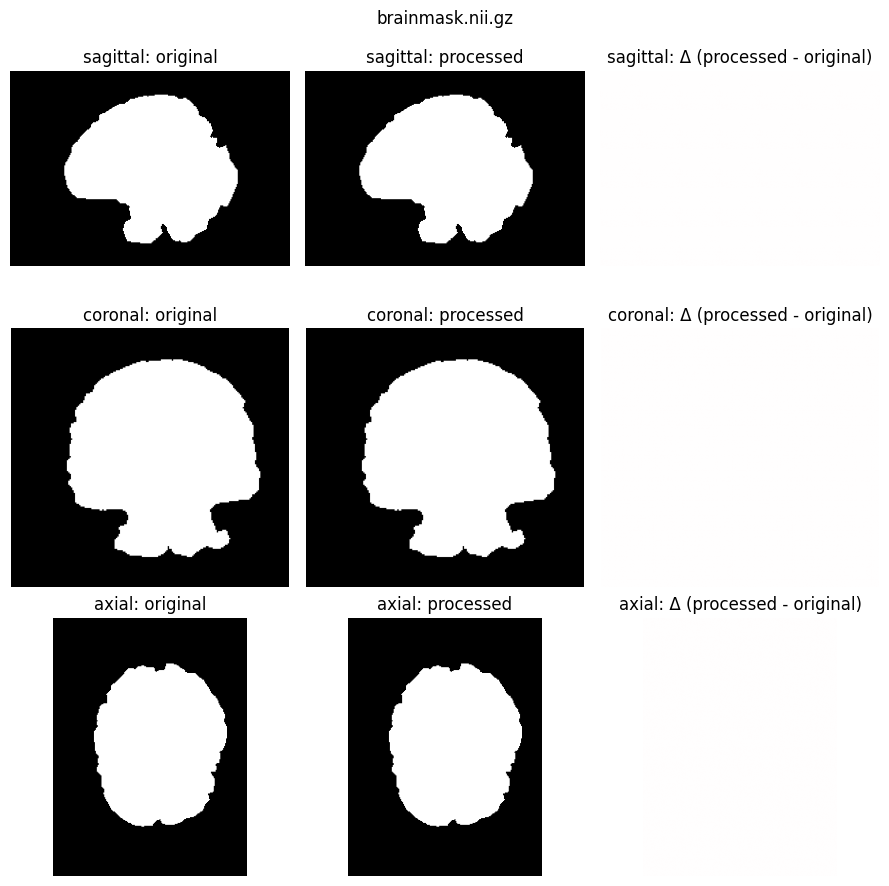

In [38]:
def show_preprocess_comparison(result, title: str):
    if result is None:
        return
    original = result.input_mask.astype(int)
    processed = result.mask.astype(int)
    delta = processed - original
    mids = [dim // 2 for dim in original.shape]
    orientations = ("sagittal", "coronal", "axial")
    slices = [
        (original[mids[0], :, :], processed[mids[0], :, :], delta[mids[0], :, :]),
        (original[:, mids[1], :], processed[:, mids[1], :], delta[:, mids[1], :]),
        (original[:, :, mids[2]], processed[:, :, mids[2]], delta[:, :, mids[2]]),
    ]
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for row, (orientation, slice_triplet) in enumerate(zip(orientations, slices)):
        orig_slice, proc_slice, delta_slice = slice_triplet
        axes[row, 0].imshow(np.rot90(orig_slice), cmap="gray")
        axes[row, 0].set_title(f"{orientation}: original")
        axes[row, 1].imshow(np.rot90(proc_slice), cmap="gray")
        axes[row, 1].set_title(f"{orientation}: processed")
        axes[row, 2].imshow(np.rot90(delta_slice), cmap="bwr", vmin=-1, vmax=1)
        axes[row, 2].set_title(f"{orientation}: Δ (processed - original)")
    for ax in axes.flat:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

if mask_result is not None:
    name = getattr(current_example, "path", None)
    title = name.name if name is not None else "Selected volume"
    show_preprocess_comparison(mask_result, title)

### Step 3: Jig parameter derivation
Translate the cleaned mask into bounding-box dimensions, padding, and slice orientation cues.

In [39]:
jig_config = gimmeJig.JigParameterConfig(
    padding_mm=10.0,
    orientation_axis=None,
)

jig_params = None
if mask_result is None:
    print("Run mask preprocessing first to compute jig parameters.")
else:
    jig_params = gimmeJig.compute_jig_parameters(current_example, mask_result, jig_config)
    print("Mask bounding box (voxel indices):")
    print(" min:", np.round(jig_params.mask_bbox_min_vox, 2))
    print(" max:", np.round(jig_params.mask_bbox_max_vox, 2))
    print("Jig bounding box (voxel indices):")
    print(" min:", np.round(jig_params.jig_bbox_min_vox, 2))
    print(" max:", np.round(jig_params.jig_bbox_max_vox, 2))
    print("Mask bounding box (mm):")
    print(" min:", np.round(jig_params.mask_bbox_min_mm, 2))
    print(" max:", np.round(jig_params.mask_bbox_max_mm, 2))
    print("Jig bounding box (mm):")
    print(" min:", np.round(jig_params.jig_bbox_min_mm, 2))
    print(" max:", np.round(jig_params.jig_bbox_max_mm, 2))
    print("Mask size (mm):", np.round(jig_params.mask_size_mm, 2))
    print("Jig size (mm):", np.round(jig_params.jig_size_mm, 2))
    print("Padding per axis (mm):", np.round(jig_params.padding_mm, 2))
    axis_labels = ["x", "y", "z"]
    axis_name = axis_labels[jig_params.orientation_axis]
    reason = jig_params.orientation_reason
    print(f"Slice axis: {axis_name} (reason: {reason})")
    print("Voxel spacing (mm):", np.round(jig_params.voxel_spacing, 3))
    print("Orientation codes:", jig_params.orientation_codes)

Mask bounding box (voxel indices):
 min: [40. 52. 20.]
 max: [184. 224. 166.]
Jig bounding box (voxel indices):
 min: [35. 47. 15.]
 max: [189. 229. 171.]
Mask bounding box (mm):
 min: [ -77.63 -119.19  -11.85]
 max: [ 67.37  53.81 135.15]
Jig bounding box (mm):
 min: [ -82.63 -124.19  -16.85]
 max: [ 72.37  58.81 140.15]
Mask size (mm): [145. 173. 147.]
Jig size (mm): [155. 183. 157.]
Padding per axis (mm): [10. 10. 10.]
Slice axis: x (reason: coarsest voxel dimension)
Voxel spacing (mm): [1. 1. 1.]
Orientation codes: ('L', 'P', 'S')


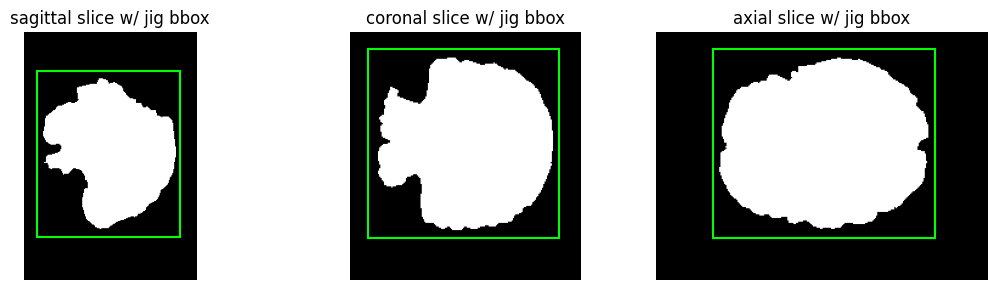

In [40]:
def plot_bbox_overlay(volume, mask_result, jig_params):
    if volume is None or mask_result is None or jig_params is None:
        return
    mask = mask_result.mask.astype(int)
    jig_mins = jig_params.jig_bbox_min_vox.astype(float)
    jig_maxs = jig_params.jig_bbox_max_vox.astype(float)

    centers = np.clip(
        np.round((jig_mins + jig_maxs) / 2.0).astype(int),
        0,
        np.array(mask.shape) - 1,
    )

    axis_info = [
        ("sagittal", 0),
        ("coronal", 1),
        ("axial", 2),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(11, 3))

    for ax, (label, axis_idx) in zip(axes, axis_info):
        slice_array = np.take(mask, centers[axis_idx], axis=axis_idx)
        other_axes = [i for i in range(3) if i != axis_idx]
        row_axis, col_axis = other_axes
        row_min, row_max = jig_mins[row_axis], jig_maxs[row_axis]
        col_min, col_max = jig_mins[col_axis], jig_maxs[col_axis]

        ax.imshow(slice_array, origin="lower", cmap="gray")
        rect = plt.Rectangle(
            (col_min - 0.5, row_min - 0.5),
            (col_max - col_min + 1.0),
            (row_max - row_min + 1.0),
            fill=False,
            edgecolor="lime",
            linewidth=1.5,
        )
        ax.add_patch(rect)
        ax.set_title(f"{label} slice w/ jig bbox")
        ax.axis("off")
    fig.tight_layout()
    plt.show()

plot_bbox_overlay(current_example, mask_result, jig_params)